Author: Jule Grimm, Johanna Rissbacher <br>
Date: 21/10

## Project BERN02

In [120]:
import pandas as pd
import numpy as np
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.metrics import accuracy_score, r2_score
from numpy.linalg import inv, svd

In [121]:
# load data
stress_data = pd.read_csv('data/Stress_wrangled.csv')

#### Data preparation
- Rename target column from `stresstype` to `target`
- Map stress categories to ordered numerical values (0, 1, 2)
- Split data by gender (male/female) for separate modeling
- Apply 80/20 train-test split for model evaluation

In [122]:
stress_data.rename(columns={'stresstype': 'target'}, inplace=True)

# Different target codes
target_order = {"Eustress (Positive Stress) - Stress that motivates and enhances performance.": 0, "No Stress - Currently experiencing minimal to no stress.": 1, "Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.": 2}
stress_data["target_ordered"] = stress_data["target"].map(target_order)

# Split in male and female
female = stress_data[stress_data['Gender'] == 1]
male = stress_data[stress_data['Gender'] == 0]

X_f = female.drop(columns=['Gender', 'target', 'target_ordered'])
y_f = female['target_ordered']

X_m = male.drop(columns=['Gender', 'target', 'target_ordered'])
y_m = male['target_ordered']

# split data
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

# define model
multi_reg_f = LogisticRegression(solver='newton-cg', max_iter=1000)
multi_reg_m = LogisticRegression(solver='newton-cg', max_iter=1000)

#### Feature selection with hyperparameter tuning for upper boundary
To identify the most predictive features we apply three best model selection methods:

1. **Forward Selection** - Adds features one by one based on improvement
2. **Backward Selection** - Removes features one by one based on performance
3. **Floating Selection** - Combines forward and backward steps for optimal selection

If we run the feature selection with `k_features='best`, the number of selected features is still very high (ca. 17 features). <br>
Our goal is to find a simple model with a high accuracy. That's why we define `k_features=(1,upper)` and do a hyperparameter tuning for the upper boundary. We vary the upper boundary in the range of 1 to 10 and calculate the accuarcy of the model when testing it on the unseen test data.

In [123]:
# Female
if 0:
    accs = [[],[],[]]
    for upper in range(1, 11):
        #-------------------------------
        # Feature selection (mlxtend)
        #-------------------------------
        # forward
        sfs_f_f = SFS(multi_reg_f, k_features=(1, upper), forward=True)
        sfs_f_f = sfs_f_f.fit(X_train_f, y_train_f)
        results_f_f = pd.DataFrame.from_dict(sfs_f_f.get_metric_dict()).T
        features_ff = list(sfs_f_f.k_feature_names_)

        # backward
        sfs_f_b = SFS(multi_reg_f, k_features=(1, upper), forward=False)
        sfs_f_b = sfs_f_b.fit(X_train_f, y_train_f)
        results_f_b = pd.DataFrame.from_dict(sfs_f_b.get_metric_dict()).T
        features_fb = list(sfs_f_b.k_feature_names_)

        # stepwise selection (floating)
        sfs_f_s = SFS(multi_reg_f, k_features=(1, upper), forward=True, floating=True)
        sfs_f_s = sfs_f_s.fit(X_train_f, y_train_f)
        results_f_s = pd.DataFrame.from_dict(sfs_f_s.get_metric_dict()).T
        features_fs = list(sfs_f_s.k_feature_names_)
        
        #-------------------------------
        # Model evaluation
        #-------------------------------
        model_ff = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_ff.fit(X_train_f[features_ff], y_train_f)
        pred_ff = model_ff.predict(X_test_f[features_ff])
        acc_ff = accuracy_score(y_test_f, pred_ff)

        model_fb = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_fb.fit(X_train_f[features_fb], y_train_f)
        pred_fb = model_fb.predict(X_test_f[features_fb])
        acc_fb = accuracy_score(y_test_f, pred_fb)

        model_fs = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_fs.fit(X_train_f[features_fs], y_train_f)
        pred_fs = model_fs.predict(X_test_f[features_fs])
        acc_fs = accuracy_score(y_test_f, pred_fs)

        accs[0].append(np.round(acc_ff, 4))
        accs[1].append(np.round(acc_fb, 4))
        accs[2].append(np.round(acc_fs, 4))
        # check accuarcy of female model
        # print(f'female forward: {np.round(acc_ff, 4)}, backward: {np.round(acc_fb, 4)}, stepwise: {np.round(acc_fs, 4)}')

    # accuracy score for every number of features and method
    accs = np.array(accs)
    df_accs = pd.DataFrame({'forward' : accs[0], 'backward': accs[1], 'floating': accs[2]})
    df_accs.to_csv('female_accuracies.csv')

In [124]:
# Male
if 0: 
    accs = [[],[],[]]
    for upper in range(1, 11):
        #-------------------------------
        # Feature selection (mlxtend)
        #-------------------------------
        # forward
        sfs_m_f = SFS(multi_reg_m, k_features=(1, upper), forward=True)
        sfs_m_f = sfs_m_f.fit(X_train_m, y_train_m)
        results_m_f = pd.DataFrame.from_dict(sfs_m_f.get_metric_dict()).T
        features_mf = list(sfs_m_f.k_feature_names_)

        # backward
        sfs_m_b = SFS(multi_reg_m, k_features=(1, upper), forward=False)
        sfs_m_b = sfs_m_b.fit(X_train_m, y_train_m)
        results_m_b = pd.DataFrame.from_dict(sfs_m_b.get_metric_dict()).T
        features_mb = list(sfs_m_b.k_feature_names_)

        # stepwise selection (floating)
        sfs_m_s = SFS(multi_reg_m, k_features=(1, upper), forward=True, floating=True)
        sfs_m_s = sfs_m_s.fit(X_train_m, y_train_m)
        results_m_s = pd.DataFrame.from_dict(sfs_m_s.get_metric_dict()).T
        features_ms = list(sfs_m_s.k_feature_names_)
        
        #-------------------------------
        # Model evaluation
        #-------------------------------
        model_mf = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_mf.fit(X_train_m[features_mf], y_train_m)
        pred_mf = model_mf.predict(X_test_m[features_mf])
        acc_mf = accuracy_score(y_test_m, pred_mf)

        model_mb = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_mb.fit(X_train_m[features_mb], y_train_m)
        pred_mb = model_mb.predict(X_test_m[features_mb])
        acc_mb = accuracy_score(y_test_m, pred_mb)

        model_ms = LogisticRegression(solver='newton-cg', max_iter=1000)
        model_ms.fit(X_train_m[features_ms], y_train_m)
        pred_ms = model_ms.predict(X_test_m[features_ms])
        acc_ms = accuracy_score(y_test_m, pred_ms)

        accs[0].append(np.round(acc_mf, 4))
        accs[1].append(np.round(acc_mb, 4))
        accs[2].append(np.round(acc_ms, 4))
        # # check accuarcy of male model
        # print(f'male forward: {np.round(acc_mf, 4)}, backward: {np.round(acc_mb, 4)}, stepwise: {np.round(acc_ms, 4)}')
    
    # accuracy score for every number of features and method
    accs = np.array(accs)
    df_accs = pd.DataFrame({'forward' : accs[0], 'backward': accs[1], 'floating': accs[2]})
    df_accs.to_csv('male_accuracies.csv')

In [125]:
# read dataframe of accuracies
df_accs_f = pd.read_csv(os.path.join('data', 'data_process', 'female_accuracies.csv'), index_col=0)
df_accs_m = pd.read_csv(os.path.join('data', 'data_process', 'male_accuracies.csv'), index_col=0)

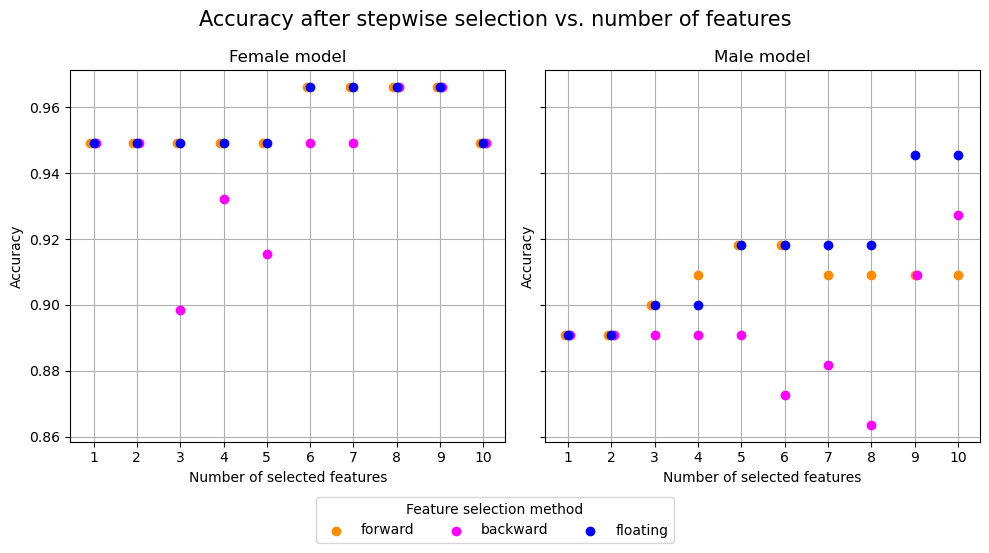

In [126]:
# Define custom color palette for legend
custom_palette = {
    'forward': 'darkorange',
    'backward': 'magenta',
    'floating': 'blue',
}

# define small shift for overlapping points
#female
shift_f_b = [0.05, 0.05, 0, 0, 0, 0, 0, 0.05, 0.05, 0.05]
#male
shift_mf = [-0.08, -0.08, -0.08, 0, -0.08, -0.08, 0, 0, 0, 0]
shift_mb = [0.05, 0.05, 0, 0, 0, 0, 0, 0, 0.05, 0]


fig, axes = plt.subplots(1, 2, figsize=(10,5), sharey=True, sharex=True)

# female subplot
for method in df_accs_f.columns:
    if method == 'forward':
        x_shifted = df_accs_f.index + 1 -0.08
    elif method == 'backward':
        x_shifted = df_accs_f.index + 1 + shift_f_b
    else:
        x_shifted = df_accs_f.index + 1  # no shift for 'floating'
    axes[0].scatter(x_shifted, df_accs_f[method], label=method, color=custom_palette[method])
axes[0].set_xlabel("Number of selected features")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Female model")
axes[0].set_axisbelow(True)
axes[0].grid('-')
axes[0].legend()
axes[0].set_xticks(np.arange(1, len(df_accs_f.index) + 1, 1))

# male subplot
for method in df_accs_m.columns:
    if method == 'forward':
        x = df_accs_m.index + 1 + shift_mf
    elif method == 'backward':
        x = df_accs_m.index + 1 + shift_mb
    else:  # 'floating'
        x = df_accs_m.index + 1
    axes[1].scatter(x, df_accs_m[method], label=method, color=custom_palette[method])
axes[1].set_xlabel("Number of selected features")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Male model")
axes[1].set_axisbelow(True)
axes[1].grid()
axes[1].legend()
axes[1].set_xticks(np.arange(1, len(df_accs_m.index) + 1, 1))

# Shared legend outside the plot
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ['forward', 'backward', 'floating'],
    title='Feature selection method',
    loc='lower center',
    ncol=3,              
    frameon=True,
    facecolor='white',
    bbox_to_anchor=(0.5, -0.1) 
)

# Remove duplicate legends inside subplots
axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.suptitle("Accuracy after stepwise selection vs. number of features", fontsize=15, ha='center')
plt.tight_layout()
plt.show()

In the female model, the accuracy was highest for 6 or more features, therefore an optimum of 6 features was selected. The forward and floating feature selection yielded the same accuracy for 6 features. We now want to check if the same features were selected in these methods. <br>

For the male model, the tradeoff between simplicity and accuracy is best in a model with 5 features.
Again, we want to check if the same features were selected in the forward and floating feature selection method.

In [127]:
## female: define model with optimum number of features
# run with forward feature selection
sfs_f_f = SFS(multi_reg_f, k_features=(1, 6), forward=True)
sfs_f_f = sfs_f_f.fit(X_train_f, y_train_f)
features_ff = list(sfs_f_f.k_feature_names_)

# stepwise selection (floating)
sfs_f_s = SFS(multi_reg_f, k_features=(1, 6), forward=True, floating=True)
sfs_f_s = sfs_f_s.fit(X_train_f, y_train_f)
features_fs = list(sfs_f_s.k_feature_names_)

# check if both methods selected the same features
print(f'Female: forward selected features: {features_ff}\n floating selected features: {features_fs}')

Female: forward selected features: ['recent_stress', 'anxiety', 'sadness', 'headaches', 'weight', 'work_env']
 floating selected features: ['recent_stress', 'anxiety', 'sadness', 'headaches', 'weight', 'work_env']


The features are the same for the forward and floating selection model, we choose the forward selection model.

In [128]:
## male: define model with optimum number of features
# forward
sfs_m_f = SFS(multi_reg_m, k_features=(1, 5), forward=True)
sfs_m_f = sfs_m_f.fit(X_train_m, y_train_m)
features_mf = list(sfs_m_f.k_feature_names_)

# stepwise selection (floating)
sfs_m_s = SFS(multi_reg_m, k_features=(1, 5), forward=True, floating=True)
sfs_m_s = sfs_m_s.fit(X_train_m, y_train_m)
features_ms = list(sfs_m_s.k_feature_names_)

# check if both methods selected the same features
print(f'Male: forward selected features: {features_mf}\n floating selected features: {features_ms}')

Male: forward selected features: ['recent_stress', 'heartbeat', 'sadness', 'workload', 'lack_conf_subjects']
 floating selected features: ['heartbeat', 'concentration', 'sadness', 'lack_conf_subjects', 'attendance']


The forward and floating feature selection did not yield the same features. Which model is 'better'? <br>

Lets check the AIC

In [129]:
# fit models with selected features and compare AIC
model_mf = LogisticRegression(solver='newton-cg', max_iter=1000)
model_mf.fit(X_train_m[features_mf], y_train_m)
pred_mf = model_mf.predict(X_test_m[features_mf])
acc_mf = accuracy_score(y_test_m, pred_mf)

model_ms = LogisticRegression(solver='newton-cg', max_iter=1000)
model_ms.fit(X_train_m[features_ms], y_train_m)
pred_ms = model_ms.predict(X_test_m[features_ms])
acc_ms = accuracy_score(y_test_m, pred_ms)

#forward
probs_mf = model_mf.predict_proba(X_test_m[features_mf])
log_like = np.sum(np.log(probs_mf[np.arange(len(y_test_m)), y_test_m]))

n_classes = 3
n_features = len(features_mf)
k = n_features * (n_classes -1) + (n_classes -1)

aic_mf = 2*k - 2*log_like

#floating
probs_ms = model_ms.predict_proba(X_test_m[features_ms])
log_like = np.sum(np.log(probs_ms[np.arange(len(y_test_m)), y_test_m]))

n_classes = 3
n_features = len(features_ms)
k = n_features * (n_classes -1) + (n_classes -1)

aic_ms = 2*k - 2*log_like
print(f'forward: {aic_mf}, floating: {aic_ms}')

forward: 79.04425735456755, floating: 79.10221183155235


Conclusion: forward selection model yielded a lower AIC -> we choose this model for the male group


### Final selected models
Female: 6 features (from forward selection) <br>
Male: 5 features (from forward selection)

In [130]:
# fit model for female
model_ff = LogisticRegression(solver='newton-cg', max_iter=1000)
model_ff.fit(X_train_f[features_ff], y_train_f)
pred_ff = model_ff.predict(X_test_f[features_ff])

# fit the model for male
model_mf = LogisticRegression(solver='newton-cg', max_iter=1000)
model_mf.fit(X_train_m[features_mf], y_train_m)
pred_mf = model_mf.predict(X_test_m[features_mf])

In [ ]:
# Inspect the coeffients and save for further plotting purposes
classes = model_ff.classes_
coef_ff = pd.DataFrame(model_ff.coef_, columns=X_test_f[features_ff].columns, index=classes) 
coef_mf = pd.DataFrame(model_mf.coef_, columns=X_test_m[features_mf].columns, index=classes)

### Visualize feature coefficients for both models

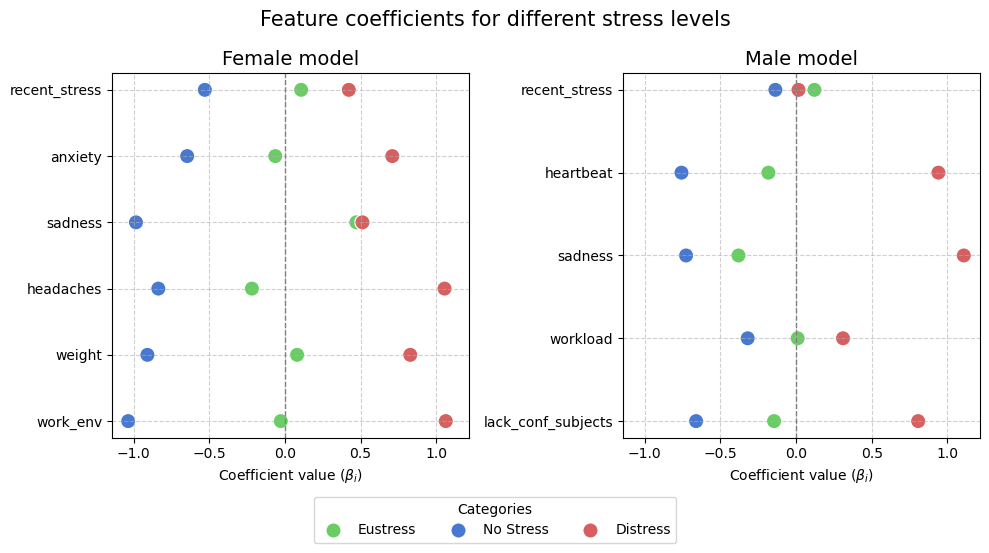

In [132]:
# Define custom colors
custom_palette = {
    0: sns.color_palette("muted")[2],  # greenish
    1: sns.color_palette("muted")[0],  # bluish
    2: sns.color_palette("muted")[3],  # reddish
}

# Create plot with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True)

# Female model
sns.scatterplot(
    data=coef_ff.reset_index().melt(id_vars='index', var_name='Column', value_name='Value'),
    x='Value',
    y='Column',
    hue='index',
    palette=custom_palette,
    s=120,
    ax=axes[0]
)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlabel(r"Coefficient value ($\beta_i$)")  # Remove x-label on top plot
axes[0].set_ylabel("")
axes[0].set_title("Female model", fontsize=14)

# Male model
sns.scatterplot(
    data=coef_mf.reset_index().melt(id_vars='index', var_name='Column', value_name='Value'),
    x='Value',
    y='Column',
    hue='index',
    palette=custom_palette,
    s=120,
    ax=axes[1]
)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xlabel(r"Coefficient value ($\beta_i$)")
axes[1].set_ylabel("")
axes[1].set_title("Male model", fontsize=14)

# Shared legend outside the plot
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ['Eustress', 'No Stress', 'Distress'],
    title='Categories',
    loc='lower center',
    ncol=3,              
    frameon=True,
    facecolor='white',
    bbox_to_anchor=(0.5, -0.1) 
)

# Remove duplicate legends inside subplots
axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.suptitle("Feature coefficients for different stress levels", fontsize=15, ha='center')
plt.tight_layout()
plt.show()

### Compute standard errors and confidence intervals for estimated parameters

In [133]:
def softmax(logits):
    """
    Compute the softmax of each row of the input array.

    Args:
        logits (np.ndarray): 2D array, containing raw model outputs (logits).

    Returns:
        np.ndarray: A 2D NumPy array of the same shape as `logits`, where each row
        contains the softmax probabilities corresponding to the input logits.
    """
    logits = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)

def hessian_se(X, B):
    """
    Compute the Hessian covariance and standard errors for the full softmax model
    (without reference class).

    Args:
        X : (n_samples, p)
            Feature matrix
        B : (p, K)
            Coefficient matrix (all K classes, not baseline-relative)

    Returns:
        H : (p*K, p*K)
            Observed information matrix (positive semi-definite)
        cov : (p*K, p*K)
            Generalized inverse (pseudoinverse) of H for covariance
        se : (p*K,)
            Standard errors for flattened coefficients
    """
    n, p = X.shape
    K = B.shape[1]
    logits = X @ B
    P = softmax(logits)

    H = np.zeros((p * K, p * K))
    for i in range(n):
        p_i = P[i]
        W_i = np.diag(p_i) - np.outer(p_i, p_i)  
        XiXiT = np.outer(X[i], X[i])             
        H += np.kron(W_i, XiXiT)

    # H is positive semidefinite but singular because of invariance
    # Use Moore-Penrose pseudoinverse instead of regular inverse
    U, s, Vt = svd(H)
    tol = 1e-10
    s_inv = np.where(s > tol, 1.0 / s, 0.0)
    cov = (Vt.T * s_inv) @ U.T
    se = np.sqrt(np.diag(cov))
    return H, cov, se

In [134]:
# Compute CI for female model
coef_f = model_ff.coef_          
intercept_f = model_ff.intercept_
betas_f = np.hstack([intercept_f[:, None], coef_f]) 
X = X_train_f[features_ff]

# Include intercept column in X first
X_aug = np.hstack([np.ones((X.shape[0], 1)), X])  
H, cov, se = hessian_se(X_aug, betas_f.T)

# 95% CIs
z = 1.96
ci_lower_f = betas_f.flatten() - z * se
ci_upper_f = betas_f.flatten() + z * se
ci_lower_f = ci_lower_f.reshape(betas_f.shape)
ci_upper_f = ci_upper_f.reshape(betas_f.shape)

# To dataframe
ci_lower_f_df = pd.DataFrame(ci_lower_f[:, 1:], columns=coef_ff.columns)
ci_upper_f_df = pd.DataFrame(ci_upper_f[:, 1:], columns=coef_ff.columns)
ci_f = pd.DataFrame({
    col: list(zip(ci_lower_f_df[col], ci_upper_f_df[col]))
    for col in ci_lower_f_df.columns
})
ci_f.iloc[0,0][0]

-0.3067682235891094

In [135]:
# Compute CI for female model
coef_m = model_mf.coef_           
intercept_m = model_mf.intercept_
betas_m = np.hstack([intercept_m[:, None], coef_m]) 
X = X_train_m[features_mf]

# Include intercept column in X first
X_aug = np.hstack([np.ones((X.shape[0], 1)), X])
H, cov, se = hessian_se(X_aug, betas_m.T)

ci_lower_m = betas_m.flatten() - z * se
ci_upper_m = betas_m.flatten() + z * se
ci_lower_m = ci_lower_m.reshape(betas_m.shape)
ci_upper_m = ci_upper_m.reshape(betas_m.shape)

# To dataframe
ci_lower_m_df = pd.DataFrame(ci_lower_m[:, 1:], columns=coef_mf.columns)
ci_upper_m_df = pd.DataFrame(ci_upper_m[:, 1:], columns=coef_mf.columns)
ci_m = pd.DataFrame({
    col: list(zip(ci_lower_m_df[col], ci_upper_m_df[col]))
    for col in ci_lower_m_df.columns
})
ci_m.iloc[0,0][0]

-0.18573526417568254

### Plot coefficients with 95% confidence intervals

In [136]:
# Prepare data to plot the coefficients shifted 
df_f = coef_ff.reset_index().melt(id_vars='index', var_name='Column', value_name='Value')
df_m = coef_mf.reset_index().melt(id_vars='index', var_name='Column', value_name='Value')

offset = 0.25
offset_dict = {0: 0, 1: offset, 2: -offset} 

# Female 
# Map categorical 'Column' to numeric and shifted positions
col_mapping_f = {col: i  for i, col in enumerate(df_f['Column'].unique())}
df_f['y_numeric'] = df_f['Column'].map(col_mapping_f)
index_mapping = {idx: offset_dict[i] for i, idx in enumerate(df_f['index'].unique())}
df_f['y_numeric_shifted'] = df_f['y_numeric'] + df_f['index'].map(index_mapping)

# CI lines
ci_lower_long_f = ci_lower_f_df.melt(var_name='Column', value_name='ci_lower')
ci_upper_long_f = ci_upper_f_df.melt(var_name='Column', value_name='ci_upper')

# Merge to align by Column and index (class)
df_ci = pd.concat([df_f, ci_lower_long_f.iloc[:,1], ci_upper_long_f.iloc[:, 1]],axis=1)

# Male
# Map categorical 'Column' to numeric and shifted positions
col_mapping_m = {col: i  for i, col in enumerate(df_m['Column'].unique())}
df_m['y_numeric'] = df_m['Column'].map(col_mapping_m)
index_mapping = {idx: offset_dict[i] for i, idx in enumerate(df_m['index'].unique())}
df_m['y_numeric_shifted'] = df_m['y_numeric'] + df_m['index'].map(index_mapping)

# FCI lines
ci_lower_long_m = ci_lower_m_df.melt(var_name='Column', value_name='ci_lower')
ci_upper_long_m = ci_upper_m_df.melt(var_name='Column', value_name='ci_upper')

# Merge to align by Column and index (class)
df_ci_m = pd.concat([df_m, ci_lower_long_m.iloc[:,1], ci_upper_long_m.iloc[:, 1]],axis=1)


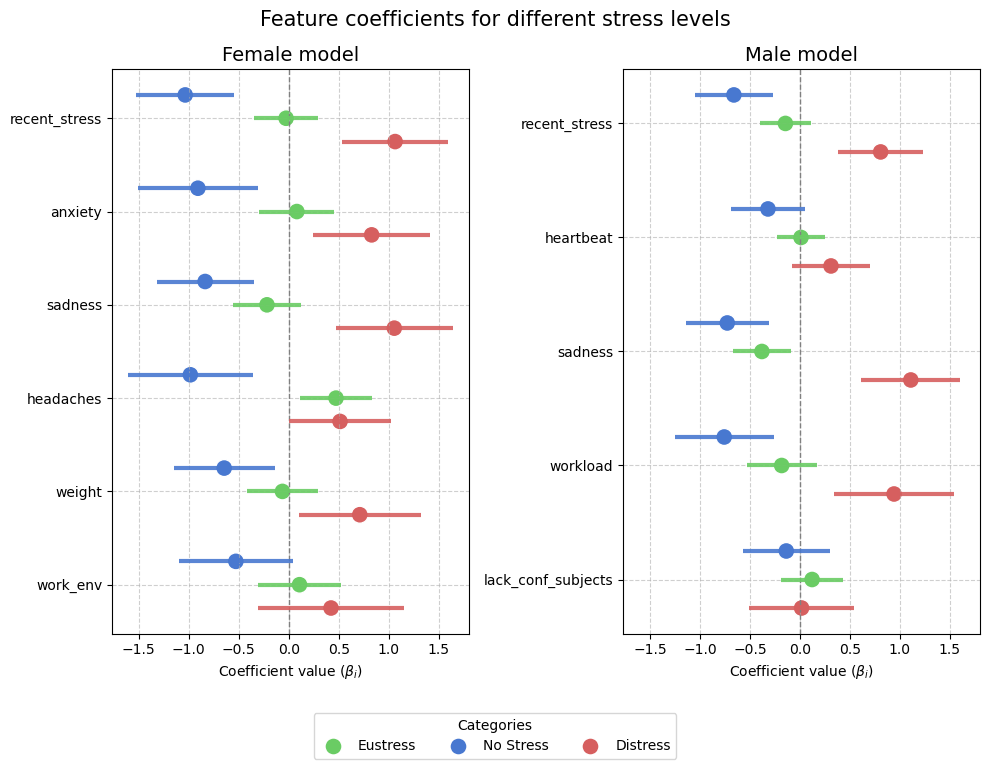

In [137]:
# Plot 
# Define custom colors
custom_palette = {
    0: sns.color_palette("muted")[2],  # greenish
    1: sns.color_palette("muted")[0],  # bluish
    2: sns.color_palette("muted")[3],  # reddish
}

fig, axes = plt.subplots(1, 2, figsize=(10,7), sharex=True)

# Female model 
sns.scatterplot(
    data=df_f,
    x='Value',
    y='y_numeric_shifted',
    hue='index',
    palette=custom_palette,
    s=150,
    ax=axes[0]
)

axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xlabel(r"Coefficient value ($\beta_i$)")  # Remove x-label on top plot
axes[0].set_ylabel("")
axes[0].set_title("Female model", fontsize=14)
axes[0].set_yticks(list(col_mapping_f.values()), list(col_mapping_f.keys())[::-1])

# Plot CIs as horizontal lines
for _, row in df_ci.iterrows():
    axes[0].hlines(
        y=row['y_numeric_shifted'],
        xmin=row['ci_lower'],
        xmax=row['ci_upper'],
        color=custom_palette[row['index']],
        alpha=0.9,
        linewidth=3
    )

# Male model
sns.scatterplot(
    data=df_m,
    x='Value',
    y='y_numeric_shifted',
    hue='index',
    palette=custom_palette,
    s=150,
    ax=axes[1]
)

axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xlabel(r"Coefficient value ($\beta_i$)")
axes[1].set_yticks(list(col_mapping_m.values()), list(col_mapping_m.keys())[::-1])
axes[1].set_ylabel("")
axes[1].set_title("Male model", fontsize=14)

# Plot CIs as horizontal lines
for _, row in df_ci_m.iterrows():
    axes[1].hlines(
        y=row['y_numeric_shifted'],
        xmin=row['ci_lower'],
        xmax=row['ci_upper'],
        color=custom_palette[row['index']],
        alpha=0.9,
        linewidth=3
    )

# Shared legend outside the plot
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ['Eustress', 'No Stress', 'Distress'],
    title='Categories',
    loc='lower center',
    ncol=3,              
    frameon=True,
    facecolor='white',
    bbox_to_anchor=(0.5, -0.1) 
)

# Remove duplicate legends inside subplots
axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.suptitle("Feature coefficients for different stress levels", fontsize=15, ha='center')
plt.tight_layout()
plt.show()


In [ ]:
# coefficients for female model
coef_ff

,recent_stress,anxiety,sadness,headaches,weight,work_env
0,0.107155,-0.063737,0.472155,-0.218332,0.080503,-0.027228
1,-0.529540,-0.646251,-0.984802,-0.836965,-0.909285,-1.036285
2,0.422385,0.709988,0.512647,1.055297,0.828782,1.063513


In [139]:
# CI interval for female model
ci_f

,recent_stress,anxiety,sadness,headaches,weight,work_env
0,"(-0.3067682235891094, 0.5210786699206057)","(-0.41868198472536033, 0.29120729055904204)","(0.11220246432521064, 0.8321074575228489)","(-0.5575621100665811, 0.12089772089391171)","(-0.29605108190147295, 0.45705657005400097)","(-0.3486237951471854, 0.2941683876696291)"
1,"(-1.100958282450533, 0.04187729591304168)","(-1.1505322021676698, -0.14196970103267292)","(-1.6066839031767617, -0.36292080732459175)","(-1.321094320307406, -0.3528360962533485)","(-1.5123498500618648, -0.30621989697191887)","(-1.5242669626338745, -0.5483032533394818)"
2,"(-0.30352569093015214, 1.148296231136627)","(0.09824276466816684, 1.3217338326984502)","(0.0024672786651268597, 1.0228275099885367)","(0.47205710470192375, 1.6385377010319468)","(0.24249906311360758, 1.4150651957674554)","(0.5350500325692583, 1.5919755908819466)"


In [140]:
# coefficients for male model
coef_mf

,recent_stress,heartbeat,sadness,workload,lack_conf_subjects
0,0.121111,-0.183116,-0.381075,0.010102,-0.145764
1,-0.137055,-0.757819,-0.727505,-0.320242,-0.661168
2,0.015944,0.940935,1.108580,0.310140,0.806932


In [141]:
# CI for male model
ci_m

,recent_stress,heartbeat,sadness,workload,lack_conf_subjects
0,"(-0.18573526417568254, 0.4279564588417839)","(-0.531427748726679, 0.16519505964075226)","(-0.6699626098095028, -0.09218781648671698)","(-0.23118304426760963, 0.2513866651254251)","(-0.4047410511697225, 0.11321261969583687)"
1,"(-0.5736922889670866, 0.29958290452247766)","(-1.2552142253900775, -0.2604235516587092)","(-1.1428193726533307, -0.31219018785820896)","(-0.6875133650641767, 0.04703023304677484)","(-1.0499419734730744, -0.2723942742087222)"
2,"(-0.5105054667901722, 0.5423936565687156)","(0.34341798335819584, 1.5384524827765542)","(0.6148493181699846, 1.6023106686377555)","(-0.08280609312545567, 0.7030856042850704)","(0.3790655966522443, 1.234799082503452)"
